In [1]:
import zipfile
import numpy as np
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.datasets
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

In [2]:
# Read the images from the zip file using the zipfile library.
zip_path = "CroppedYale.zip"
extract_path = "CroppedYale"

# Extract images from the zip file and store it under "CroppedYale".
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
# Create the array of image vectors. 

dataset_path = "CroppedYaleCopy/CroppedYale Project Data/CroppedYale"

images = [] # To store the images 
labels = [] # To store the labels. 

for subject in sorted(os.listdir(dataset_path)):
    
    subject_path = os.path.join(dataset_path, subject)
    
    if not os.path.isdir(subject_path):
        continue
        
    for file in os.listdir(subject_path):
        
        # Skip ambient images if any have been detected. 
        if "Ambient" in file:
            continue
            
        if file.endswith(".pgm"):
            
            path = os.path.join(subject_path, file)
            img = imageio.imread(path)
            
            images.append(img) # Append images. 
            labels.append(subject) # Append label to be the number of the person whose image it is. 

X = np.array(images) # Comvert to array.
y = np.array(labels) # Convert labels to array

print("Dataset shape:", X.shape)

/tmp/ipykernel_614/4179951614.py:24: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


Dataset shape: (2414, 192, 168)


In [4]:
# Normalize the image vectors. 
# This is important for training the CNN. 

X = X.astype("float32") 
X = (X - X.min()) / (X.max() - X.min()) 
print(X.shape)

(2414, 192, 168)


In [5]:
# Here we generate the occlusions and masks:

np.random.seed(42)   # we use this same random seed in all experiments to get identical masks

N, H, W = X.shape

X_occluded = X.copy()
masks = np.zeros_like(X)

for i in range(N):

    # generate random masks of size 15–30% of image size
    mask_h = np.random.randint(int(H * 0.15), int(H * 0.30))
    mask_w = np.random.randint(int(W * 0.15), int(W * 0.30))

    # generate random position to insert the mask.
    y = np.random.randint(0, H - mask_h)
    x = np.random.randint(0, W - mask_w)

    # apply mask to images. 
    X_occluded[i, y:y+mask_h, x:x+mask_w] = 0
    masks[i, y:y+mask_h, x:x+mask_w] = 1

print("Occluded dataset shape:", X_occluded.shape)
print("Mask shape:", masks.shape)

Occluded dataset shape: (2414, 192, 168)
Mask shape: (2414, 192, 168)


In [7]:
# Here we can see that the mask layer basically represents each pixel where the mask is as 1 (white),
# and the unmasked pixels remain as 0 (black). We see this in the next slide where we print out a mask. 
np.unique(masks[0, :, :])

array([0., 1.], dtype=float32)

In [6]:
# Add channels:
X_clean_cnn = np.expand_dims(X, axis=1)
X_occluded_cnn = np.expand_dims(X_occluded, axis=1)
X_mask_cnn = np.expand_dims(masks, axis=1)

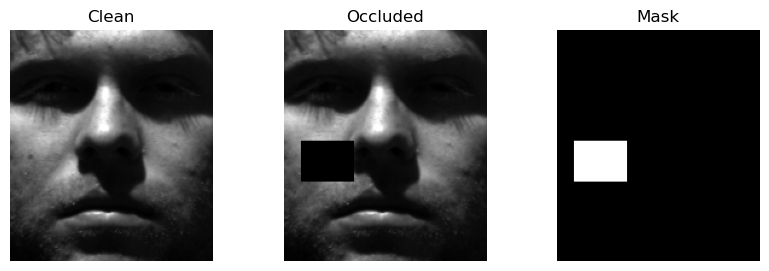

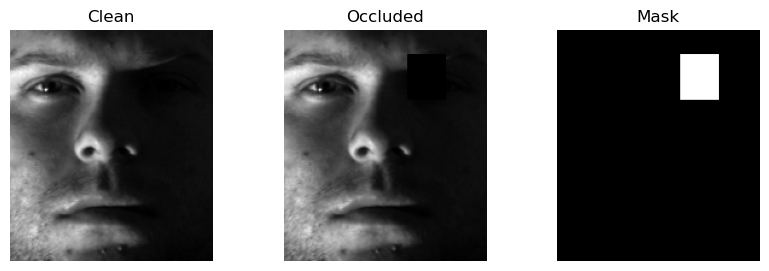

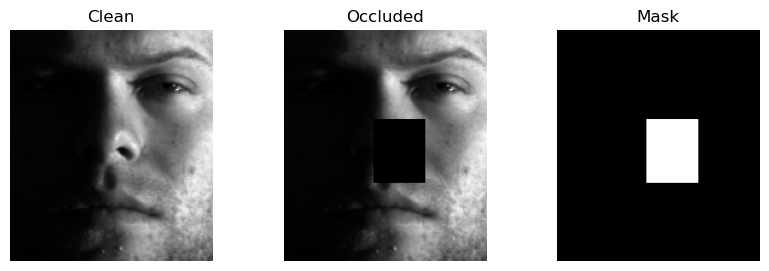

In [127]:
# Check if the occlusions were created successfully by printing out one set of clean, occluded and mask:
for i in range(3):

    clean = X[i]
    occ = X_occluded[i]
    mask = X_mask_cnn[i, 0]

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Clean")
    plt.imshow(clean, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Occluded")
    plt.imshow(occ, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.show()

In [128]:
# Train and Test splits:
X_train_occ, X_test_occ, \
X_train_clean, X_test_clean, \
X_train_mask, X_test_mask = train_test_split(

    X_occluded_cnn,
    X_clean_cnn,
    X_mask_cnn,
    test_size=0.2,
    random_state=42
)

In [129]:
# # Add channels similar to earlier. 
# X_train_occ = np.expand_dims(X_train_occ,1)
# X_test_occ = np.expand_dims(X_test_occ,1)

# X_test_mask = np.expand_dims(X_test_mask,1)
# X_train_mask = np.expand_dims(X_train_mask,1)

# X_train_clean = np.expand_dims(X_train_clean,1)
# X_test_clean = np.expand_dims(X_test_clean,1)

In [130]:
print(X_train_occ.shape[0])

1931


In [131]:
# Converting the training and testing image sets into tensors. 
X_train_occ = torch.tensor(X_train_occ, dtype=torch.float32)
X_train_clean = torch.tensor(X_train_clean, dtype=torch.float32)
X_train_mask = torch.tensor(X_train_mask, dtype=torch.float32)

X_test_occ = torch.tensor(X_test_occ, dtype=torch.float32)
X_test_clean = torch.tensor(X_test_clean, dtype=torch.float32)
X_test_mask = torch.tensor(X_test_mask, dtype=torch.float32)

In [132]:
# The train and test image sets that have been converted into tensors:
train_dataset = TensorDataset(X_train_occ, X_train_clean, X_train_mask)
test_dataset = TensorDataset(X_test_occ, X_test_clean, X_test_mask)

# Use the train_loader to decide the batch size to be used for each epoch. The images are chosen randomly through setting the parameter
# shuffle = true. 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [133]:
class UNet(nn.Module): # Define the neural net
    def __init__(self):
        super().__init__()

        # Encoder: 
        
        # Kernel size = 3 x 3.
        # Padding = 1.
        
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)  # Input channels = 1 because our images are grayscale. Output = 32 feature maps.
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1) # Input channels = 32 feature maps. Output = 64 feature maps.
        self.enc3 = nn.Conv2d(64, 128, 3, padding=1) # Input channels = 64 feature maps. Output = 128 feature maps.

        # Decoder :
        # Here we peform deconvolution. 
        self.dec1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = nn.Conv2d(128, 64, 3, padding=1)

        self.dec2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv2 = nn.Conv2d(64, 32, 3, padding=1)

        self.out = nn.Conv2d(32, 1, 1)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        # Encoder:
        # Apply convolution and ReLu. Downsample using pooling. 
        e1 = F.relu(self.enc1(x))
        p1 = self.pool(e1)

        e2 = F.relu(self.enc2(p1))
        p2 = self.pool(e2)

        e3 = F.relu(self.enc3(p2))

        # Decoder
        d1 = self.dec1(e3)

        # concatenate skip connection
        d1 = torch.cat([d1, e2[:, :, :d1.shape[2], :d1.shape[3]]], dim=1)

        d1 = F.relu(self.conv1(d1))

        d2 = self.dec2(d1)

        d2 = torch.cat([d2, e1[:, :, :d2.shape[2], :d2.shape[3]]], dim=1) # We concatenate the encoder features and decoder features. 

        d2 = F.relu(self.conv2(d2))

        out = torch.sigmoid(self.out(d2)) # Apply sigmoid function. 

        return out

In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

In [135]:
# Define the criterion for training, and the optimizer to be used. 
# We use ADAM which is Adaptive Momentum Gradient descent. Uses momentum in calculating the update and dynamically updates the learning 
# rate.
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [136]:
# Train the U-net for 75 epochs. 
epochs = 200

# Loop over number of epochs.
for epoch in range(epochs):

    # Start training. 
    model.train()
    total_loss = 0

    # Loop over every occluded and clean image pair. 
    for occluded, clean, mask in train_loader:

        # Load occluded and clean images to GPU memory.
        occluded = occluded.to(device)
        clean = clean.to(device)
        mask = mask.to(device)

        # We reinitialize the gradient to 0 in every batch of occluded and clean image pairs. 
        optimizer.zero_grad()

        # Perform the convolution and get the output reconstructed image.
        pred = model(occluded)
        recon = occluded * (1 - mask) + pred * mask
        mask_weight = 5.0

        # Caclulate the loss or error rate based on the criterion we chose which was MSELoss.
        # MSELoss compares each pixel and squares the difference to the pixel in the target.
        # It then averages this squared error to get the mean squared loss. 
        loss = ((recon - clean)**2 * (1 + mask_weight * mask)).mean()

        # Perform backpropogation and perform update of the weights using gradient descent. 
        # Note: The optimization in done through mini-batch gradient descent. 
        loss.backward()
        optimizer.step()

        # Sum the loss to get the total. 
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.013253963898775006
Epoch 2, Loss: 0.008556389857914822
Epoch 3, Loss: 0.007949576278271015
Epoch 4, Loss: 0.007719352504638724
Epoch 5, Loss: 0.007645526429453541
Epoch 6, Loss: 0.007482284195105399
Epoch 7, Loss: 0.007321689014269178
Epoch 8, Loss: 0.007189053791952281
Epoch 9, Loss: 0.006832582747163482
Epoch 10, Loss: 0.006520820317851487
Epoch 11, Loss: 0.006317757535725832
Epoch 12, Loss: 0.006195277887712087
Epoch 13, Loss: 0.005936592265055322
Epoch 14, Loss: 0.0058396896828458575
Epoch 15, Loss: 0.005783122394634179
Epoch 16, Loss: 0.005982847422484524
Epoch 17, Loss: 0.005660129062569708
Epoch 18, Loss: 0.005623737567543121
Epoch 19, Loss: 0.005490553421006838
Epoch 20, Loss: 0.005501715533727827
Epoch 21, Loss: 0.005402212116813426
Epoch 22, Loss: 0.005366531597096319
Epoch 23, Loss: 0.005298947977009884
Epoch 24, Loss: 0.005295943946015736
Epoch 25, Loss: 0.005209236754073708
Epoch 26, Loss: 0.00521880293010988
Epoch 27, Loss: 0.005170861705521907
Epoch 28, 

In [137]:
# Generate reconstructions of the images. 
model.eval() # Model in evaluation mode.

with torch.no_grad(): #No_grad implies that no gradients are computed since we are not going to backpropogate. 
    sample = X_test_occ[:1].to(device) # Pick an image to see the reconstruction for.

    reconstruction = model(sample) # Perform reconstruction. 

reconstruction = reconstruction.cpu().numpy()

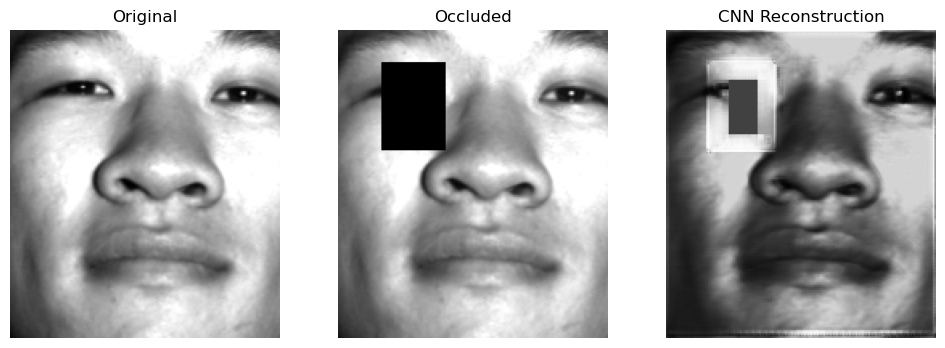

In [138]:
# Viasualization an example of the models reconstruction: 

idx = 0

clean = X_test_clean[idx].cpu().numpy().squeeze()
occ = X_test_occ[idx].cpu().numpy().squeeze()

with torch.no_grad(): # Telling the model not to calculate gradients because we are not going to backpropogate. 
    recon = model(X_test_occ[idx:idx+1].to(device)) # Generate a reconstruction. 

recon = recon.cpu().numpy().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(clean, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Occluded")
plt.imshow(occ, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("CNN Reconstruction")
plt.imshow(recon, cmap='gray')
plt.axis('off')

plt.show()

In [139]:
# Get all the evaluation metrics we are going to use to compare the reconstruction by the models: 
model.eval() # Model in evaluation mode. 

mse_total = 0
mae_total = 0
num_pixels = 0
ssim_scores = []

with torch.no_grad(): # Does not calculate the gradients because we are not going to backpropogate. 
    for occluded, clean, mask in test_loader:

        occluded = occluded.to(device)
        clean = clean.to(device)
        mask = mask.to(device)

        pred = model(occluded) # Generate the model's guess off the target image. 

        # Reconstruct the image.
        # Here we are adding the unmasked pixels and the predictions of model over the masked pixels. 
        # pred * mask gives the predicted pixel values for the mask area. 
        # We add this to occluded * (1 - mask) which signifies the pixels from the original image that were not masked.
        # In particular, mask pixels are represented as 1 to indicate the mask is, so for all those pixels (1-mask) = 0. 
        recon = occluded * (1 - mask) + (pred * mask) 
        
        masked_pixels = mask.sum().item() # This gives the number of pixels that are inside the mask only. 
        if masked_pixels == 0: # Check for incase there was no mask in the image passed. 
            continue

        # Calculate the error in only the mask area. 
        # Again, mask pixels are represented as 1 so this is only getting the error for those pixels. 
        diff = (recon - clean) * mask 

        # MSE
        mse_total += torch.sum(diff ** 2).item() # Calculate the mean squared error. 

        # MAE
        mae_total += torch.sum(torch.abs(diff)).item() # Calculate the mean absolute error. 

        # SSIM : Structural Similarity Index. It compares luminance, contrast, and structure.
        # unlike the other metrics, SSIM is being caluclated for the entire image, not just the mask.
        # This is because we are using SSIM as a measure for perceptual similiarty of the image as a whole
        # to compare it to how humans would perceive the image. 
        # Convert the reconstructed image to numpy array: 
        for i in range(recon.shape[0]):
            # recon_np = recon[i,0].cpu().numpy()
            # clean_np = clean[i,0].cpu().numpy()
            recon_np = recon[i].squeeze().cpu().numpy()
            clean_np = clean[i].squeeze().cpu().numpy()
            # Append SSIM score. The higher the better. 
            ssim_scores.append(ssim(clean_np, recon_np, data_range=1.0))

# Final metrics
mse = mse_total / masked_pixels # Average the squared error over the number of pixels. 
mae = mae_total / masked_pixels # Average the absolute error over the number of pixels. 
psnr = 10 * np.log10(1 / mse) # Calculate the peak signal-to-noise ratio. The higher the better reconstruction. 
ssim_score = np.mean(ssim_scores) # Average the SSIM scores. 

print("MSE:", mse)
print("MAE:", mae)
print("PSNR:", psnr)
print("SSIM:", ssim_score)

MSE: 0.01712854340440805
MAE: 0.07674907369903108
PSNR: 17.66279567467921
SSIM: 0.9756175392338667
